## Test for Plotting All Regions 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
import os
import shutil
from astropy.io import fits # importing fits 
from astropy.utils.data import download_file # simple method of downloading FITS file 
from astropy.visualization import astropy_mpl_style # resource for organized plots
from astropy.visualization import ZScaleInterval, MinMaxInterval, AsinhStretch, LogStretch, ImageNormalize # quality image display/visualization
from astropy.wcs import WCS #coordinate conversion
from regions import Regions # import astropy region class


In [2]:
class DisplayData: 
    """" A class to open FITS file, display image data, 
         and plot a DS9.reg file onto the image data. """ 
    def __init__(self, filepath):
        """ Initialize through opening the data.""" 
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul: # opening file
            data = None
            header = None
            for hdu in hdul: #loops through each extension (HDU) in the list of HDUs to check if data has dimensions (thanks rav!)
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
       # hdu = fits.open(filepath)[1] #okay index 1 isn't always gong to work. you need to write an if statement to test 0


    def display_header(self, filepath):
        self.filepath = filepath
        from astropy.io import fits 
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")

    def display_image(self, filepath, norm, vmin, vmax):
        self.filepath = filepath 
        self.norm = norm
        self.vmin = vmin
        self.vmax = vmax
        #brightness control
        #hdu = fits.open(filepath)[1]
        #data = hdu.data
        #header = hdu.header 
        from astropy.io import fits
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")



        plt.figure(figsize=(8, 8))
        plt.imshow(data, cmap="gray", origin="lower", norm=self.norm, vmin=self.vmin, vmax=self.vmax) #figure out a way to add normalization parameter into this function
        plt.colorbar(label="Intensity", fraction=0.0146, aspect=20)
    

    
    def plot_region(self, filepath, disk_regionfile, ring_regionfile, bar_regionfile, center_regionfile, norm, vmin, vmax):
        self.filepath = filepath
        self.disk_regionfile = disk_regionfile
        self.ring_regionfile = ring_regionfile
        self.bar_regionfile = bar_regionfile
        self.center_regionfile = center_regionfile
        self.norm = norm 
        self.vmin = vmin
        self.vmax= vmax 
        from astropy.io import fits 
        from astropy.wcs import WCS
        with fits.open(filepath) as hdul:
            data = None
            header = None
            for hdu in hdul:
                if hdu.data is not None and hdu.header.get("NAXIS",0) >= 2:
                    data = hdu.data 
                    header = hdu.header 
                    print(f"Found data in extension: {hdu.name or hdul.index(hdu)}")
                    break 
            
        if data is None:
            print("None")
            
        wcs = WCS(header) #see https://astronomy.stackexchange.com/questions/51673/how-to-slice-wcs-in-a-fits-file
        # access region file via parsing & converting data from wcs to pixel. the 0 is for the FIRST region plotted
        # for i in regionfile??? what i want to do is for each region in the regionfile, plot each region if an index exists for that region
      
        disk_region = Regions.read(disk_regionfile)[0].to_pixel(wcs)
        ring_region1 = Regions.read(ring_regionfile)[0].to_pixel(wcs) # access region file via
        ring_region2 = Regions.read(ring_regionfile)[1].to_pixel(wcs) # the one corresponds to
        bar_region = Regions.read(bar_regionfile)[0].to_pixel(wcs)
        bar_region2 = Regions.read (bar_regionfile)[1].to_pixel(wcs)
        center_region = Regions.read(center_regionfile)[0].to_pixel(wcs)
        fig, ax = plt.subplots()
        ax.imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax) 
        disk_region.plot(ax=ax, color='red', lw=2.0)
        ring_region1.plot(ax=ax, color= 'blue', lw=2.0) 
        ring_region2.plot(ax=ax, color='blue', lw=2.0)
        bar_region.plot(ax=ax, color= 'green', lw=1.0)
        bar_region2.plot(ax=ax, color= 'green', lw=1.0)
        center_region.plot(ax=ax, color='orange', lw=1.0)
        
        plt.savefig('H-alpha, 3Regions')
                        



## H-alpha: MUSE

Found data in extension: HA6562_FLUX
Found data in extension: HA6562_FLUX


C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\ellipse.py:222: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Ellipse(xy=xy, width=width, height=height, angle=angle,
C:\Users\Lamat\AppData\Local\Programs\Python\Python314\Lib\site-packages\regions\shapes\rectangle.py:219: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Rectangle(xy=xy, width=width, height=height,


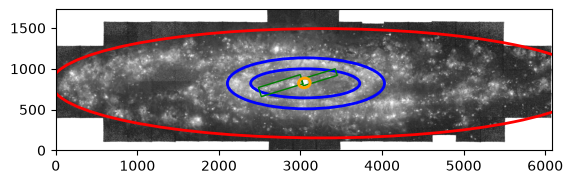

In [5]:
ha_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\NGC0253_Ha.fits"
ha_data = DisplayData(ha_file)
ha_disk_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/disk_ha_regionfile_adjusted71626_muse.reg"
ha_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_ha_regionfile_muse_2.reg"
ha_bar_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/bar_ha_regionfile_muse_twoboxes.reg"
ha_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_ha_regionfile_muse.reg"
ha_data.plot_region(ha_file, ha_disk_regionfile, ha_ring_regionfile, ha_bar_regionfile, ha_center_regionfile, norm = 'log', vmin=30, vmax=30000)


## IRAC4: Spitzer

In [3]:
%matplotlib widget
irac4_file = r"C:\Users\Lamat\OneDrive - The Ohio State University\Lamat NGC 253 Environment Mask\Plotting Regions\ngc0253_irac4_gauss4p0.fits"
irac4_data = DisplayData(irac4_file)
irac4_disk_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/disk_irac_regionfile_adjusted71326_spitzer.reg"
irac4_ring_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_irac_regionfile_spitzer.reg"
irac4_center_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/center_irac4_regionfile_spitzer.reg"
irac4_bar_regionfile = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/bar_irac4_regionfile_spitzer_twoboxes.reg"

Found data in extension: PRIMARY


### Failed attempts at a loop to plot regions (reference?):

In [ ]:
#see https://astronomy.stackexchange.com/questions/51673/how-to-sLice-wcs-in-a-fits-file

# okay i'm testing this out using documentation from https://pyregion.readthedocs.io/en/latest/getting_started.html. im changing all of the pyregion stuff to the Regions package ive been using, but the code is exactly what i need i think (famous last words)
ha_region = r"C:\Users\Lamat\OneDrive - The Ohio State University/Lamat NGC 253 Environment Mask/Plotting Regions/ring_ha_regionfile_muse_2.reg"
ha_r = Regions.read(ha_region, format='ds9')
# access region file via parsing & converting data from wes to pixel. the a is for the FIRST region plotted
# for i in regionfile??? what i want to do is for each region in the regionfile, plot each region if an ind
for i in range(len(regionfile)): #https://stackoverfLow.com/questions/21162624/indexing-float-values-in-pyt
# for each index in the regionfile
    wcs = WCS (header)
    region = Regions. read (regionfile) [i].to_pixel(wcs)
    fig, ax = plt. subplots()
    ax. imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax)
    region.plot(ax=ax, color='blue', lw=2.0)
    break


wcs = WCS (header) #see https://astronomy.stackexchange.com/questions/51673/how-to-sLice-wcs-in-a-fits-file
# access region file via parsing & converting data from wes to pixel. the @ is for the FIRST region plotted
# for i in regionfile??? what i want to do is for each region in the regionfile, plot each region if an index exists
fig, ax = plt.subplots()
for i in range(len(regionfile)): #https://stackoverflow.com/questions/21162624/indexing-float-values-in-pyt
# for each index in the regionfile
    region = Regions.read (regionfile)
    if region == Regions.read(regionfile)[0].to_pixel(wcs) is True:
    ax.imshow(data, cmap='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax)
    region.plot(ax=ax, color=self.color, Iw=2.0) #plots
    #opening one region at a time in the regionfile and converts from wes coords to pixel coord 
    elif region == Regions.read (regionfile) [1].to pixel(wcs) is True:
        ax. imshow(data, map='gray', origin='lower', norm=self.norm, vmin=self.vmin, vmax=self.vmax)
        region.plot(ax=ax, color=self.color, 1w=2.0) #plot
    else:
        print("No data at indexed value.")
